In [ ]:
# Download the MNIST dataset
# https://www.kaggle.com/datasets/hojjatk/mnist-dataset/data

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
import struct

In [7]:
data_path = "../Dataset/archive"

train_images_path = os.path.join(data_path, "train-images.idx3-ubyte")
train_labels_path = os.path.join(data_path, "train-labels.idx1-ubyte")
test_images_path = os.path.join(data_path, "t10k-images.idx3-ubyte")
test_labels_path = os.path.join(data_path, "t10k-labels.idx1-ubyte")

In [8]:
class Dataset:
    def __init__(self, images_path, labels_path):
        self.images = self.load_images(images_path)
        self.labels = self.load_labels(labels_path)

    def load_images(self, path):
        with open(path, "rb") as f:
            magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
            images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28 * 28)
        return images

    def load_labels(self, path):
        with open(path, "rb") as f:
            magic, num = struct.unpack(">II", f.read(8))
            labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

Number of training samples: 60000
Number of test samples: 10000


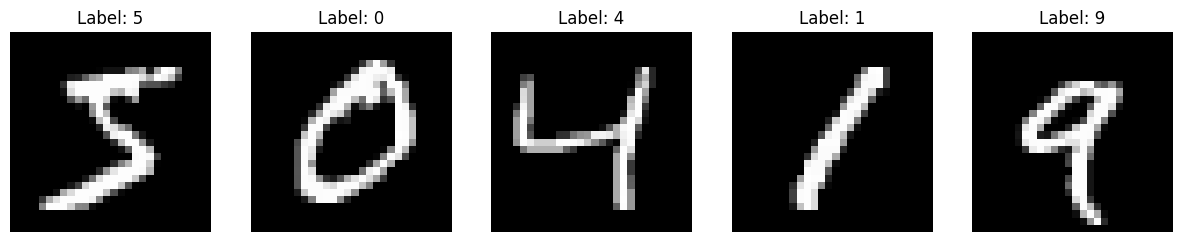

In [ ]:
train_dataset = Dataset(train_images_path, train_labels_path)
test_dataset = Dataset(test_images_path, test_labels_path)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    image, label = train_dataset[i]
    axes[i].imshow(image.reshape(28, 28), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")
plt.show()

In [11]:
class Dataloader:
    def __init__(self, dataset, batch_size=64, shuffle=True):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(dataset))
        if shuffle:
            np.random.shuffle(self.indices)

    def __iter__(self):
        self.current_idx = 0
        return self

    def __next__(self):
        if self.current_idx >= len(self.dataset):
            raise StopIteration
        batch_indices = self.indices[
            self.current_idx : self.current_idx + self.batch_size
        ]
        batch_images = np.array([self.dataset[i][0] for i in batch_indices])
        batch_labels = np.array([self.dataset[i][1] for i in batch_indices])
        self.current_idx += self.batch_size
        return batch_images, batch_labels